In [44]:
!pip install dash

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from dash import Dash, dcc, html, Input, Output

# Load the dataset
df = pd.read_csv('Air_Quality.csv')  # Upload this in Colab




In [46]:
print("First few rows of the dataset:")
display(df.head())

# Display basic information about the dataset
print("\nDataset Information:")
display(df.info())

# Display basic statistics
print("\nBasic Statistics:")
display(df.describe())

First few rows of the dataset:


,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value,Message
0,179772,640,Boiler Emissions- Total SO2 Emissions,Number per km2,number,UHF42,409.0,Southeast Queens,2015,01/01/2015,0.3,NaN
1,221956,386,Ozone (O3),Mean,ppb,UHF34,305307.0,Upper East Side-Gramercy,Summer 2014,06/01/2014,24.9,NaN
2,221806,386,Ozone (O3),Mean,ppb,UHF34,103.0,Fordham - Bronx Pk,Summer 2014,06/01/2014,30.7,NaN
3,221836,386,Ozone (O3),Mean,ppb,UHF34,204.0,East New York,Summer 2014,06/01/2014,32.0,NaN
4,221812,386,Ozone (O3),Mean,ppb,UHF34,104.0,Pelham - Throgs Neck,Summer 2014,06/01/2014,31.9,NaN



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18025 entries, 0 to 18024
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unique ID       18025 non-null  int64  
 1   Indicator ID    18025 non-null  int64  
 2   Name            18025 non-null  object 
 3   Measure         18025 non-null  object 
 4   Measure Info    18025 non-null  object 
 5   Geo Type Name   18025 non-null  object 
 6   Geo Join ID     18016 non-null  float64
 7   Geo Place Name  18016 non-null  object 
 8   Time Period     18025 non-null  object 
 9   Start_Date      18025 non-null  object 
 10  Data Value      18025 non-null  float64
 11  Message         0 non-null      float64
dtypes: float64(3), int64(2), object(7)
memory usage: 1.7+ MB


None


Basic Statistics:


,Unique ID,Indicator ID,Geo Join ID,Data Value,Message
count,18025.000000,18025.000000,1.801600e+04,18025.000000,0.0
mean,426387.692705,434.830180,5.906303e+05,21.428616,NaN
std,250489.450630,115.852371,7.769549e+06,23.999345,NaN
min,121644.000000,365.000000,1.000000e+00,0.000000,NaN
25%,175303.000000,365.000000,2.020000e+02,8.900000,NaN
50%,410803.000000,375.000000,3.030000e+02,15.200000,NaN
75%,649893.000000,386.000000,4.040000e+02,26.700000,NaN
max,828353.000000,661.000000,1.051061e+08,424.700000,NaN


In [47]:
# Check for missing values
print("Missing Values in Each Column:")
display(df.isnull().sum())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

Missing Values in Each Column:


,0
Unique ID,0
Indicator ID,0
Name,0
Measure,0
Measure Info,0
Geo Type Name,0
Geo Join ID,9
Geo Place Name,9
Time Period,0
Start_Date,0



Number of duplicate rows: 0


In [48]:
# removing the message column
df = df.drop(columns=['Message'])
display(df.head())
# Clean data
df['Start_Date'] = pd.to_datetime(df['Start_Date'], errors='coerce')
df['Year'] = df['Start_Date'].dt.year
df = df.dropna(subset=['Data Value', 'Geo Place Name', 'Name'])

,Unique ID,Indicator ID,Name,Measure,Measure Info,Geo Type Name,Geo Join ID,Geo Place Name,Time Period,Start_Date,Data Value
0,179772,640,Boiler Emissions- Total SO2 Emissions,Number per km2,number,UHF42,409.0,Southeast Queens,2015,01/01/2015,0.3
1,221956,386,Ozone (O3),Mean,ppb,UHF34,305307.0,Upper East Side-Gramercy,Summer 2014,06/01/2014,24.9
2,221806,386,Ozone (O3),Mean,ppb,UHF34,103.0,Fordham - Bronx Pk,Summer 2014,06/01/2014,30.7
3,221836,386,Ozone (O3),Mean,ppb,UHF34,204.0,East New York,Summer 2014,06/01/2014,32.0
4,221812,386,Ozone (O3),Mean,ppb,UHF34,104.0,Pelham - Throgs Neck,Summer 2014,06/01/2014,31.9


In [49]:
# Convert Name column to list for better analysis
df['Name_list'] = df['Name'].str.split(',')

# Get unique pollutant types
all_pollutants = set([item.strip() for sublist in df['Name_list'] for item in sublist if isinstance(sublist, list)])
print(f"\nNumber of Unique Pollutant Types: {len(all_pollutants)}")
print("\nSample of Pollutant Types:")
print(list(all_pollutants)[:10])

# Create Data Value Range categories for better insights
df['Value_Range'] = pd.cut(df['Data Value'],
                          bins=[0, 10, 20, 50, 100, 200, 500],
                          labels=['Very Low', 'Low', 'Moderate', 'High', 'Very High', 'Severe'])

# Function to get primary pollutant (first in the list)
def get_primary_pollutant(name_list):
    if isinstance(name_list, list) and len(name_list) > 0:
        return name_list[0].strip()
    return None

df['Primary_Pollutant'] = df['Name_list'].apply(get_primary_pollutant)

# Display the updated dataframe
display(df[['Geo Place Name', 'Data Value', 'Value_Range', 'Name', 'Primary_Pollutant']].tail())



Number of Unique Pollutant Types: 18

Sample of Pollutant Types:
['Asthma hospitalizations due to Ozone', 'Boiler Emissions- Total SO2 Emissions', 'Annual vehicle miles traveled (trucks)', 'Boiler Emissions- Total PM2.5 Emissions', 'Outdoor Air Toxics - Formaldehyde', 'Nitrogen dioxide (NO2)', 'Boiler Emissions- Total NOx Emissions', 'Cardiovascular hospitalizations due to PM2.5 (age 40+)', 'Cardiac and respiratory deaths due to Ozone', 'Deaths due to PM2.5']


,Geo Place Name,Data Value,Value_Range,Name,Primary_Pollutant
18020,Tottenville and Great Kills (CD3),12.9,Low,Annual vehicle miles traveled,Annual vehicle miles traveled
18021,Tottenville and Great Kills (CD3),14.7,Low,Annual vehicle miles traveled,Annual vehicle miles traveled
18022,Canarsie - Flatlands,43.4,Moderate,Annual vehicle miles traveled,Annual vehicle miles traveled
18023,Southwest Queens,65.8,High,Annual vehicle miles traveled,Annual vehicle miles traveled
18024,Jamaica,41.0,Moderate,Annual vehicle miles traveled,Annual vehicle miles traveled


<ipython-input-50-2da85ee65c09>:12: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




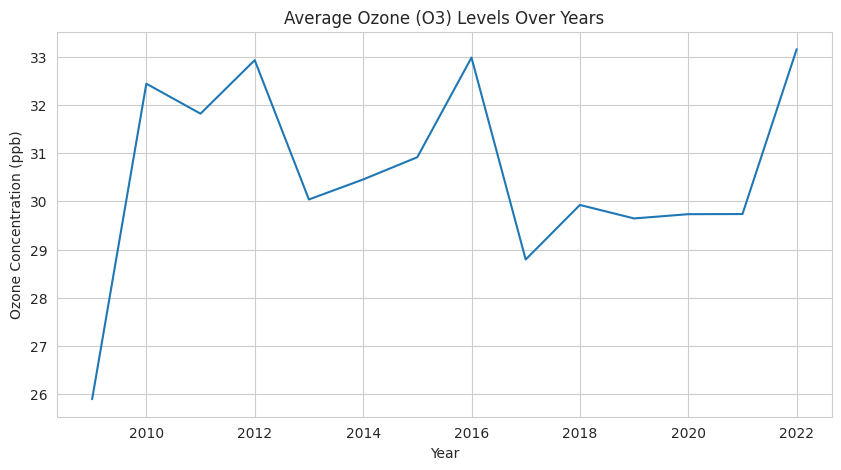

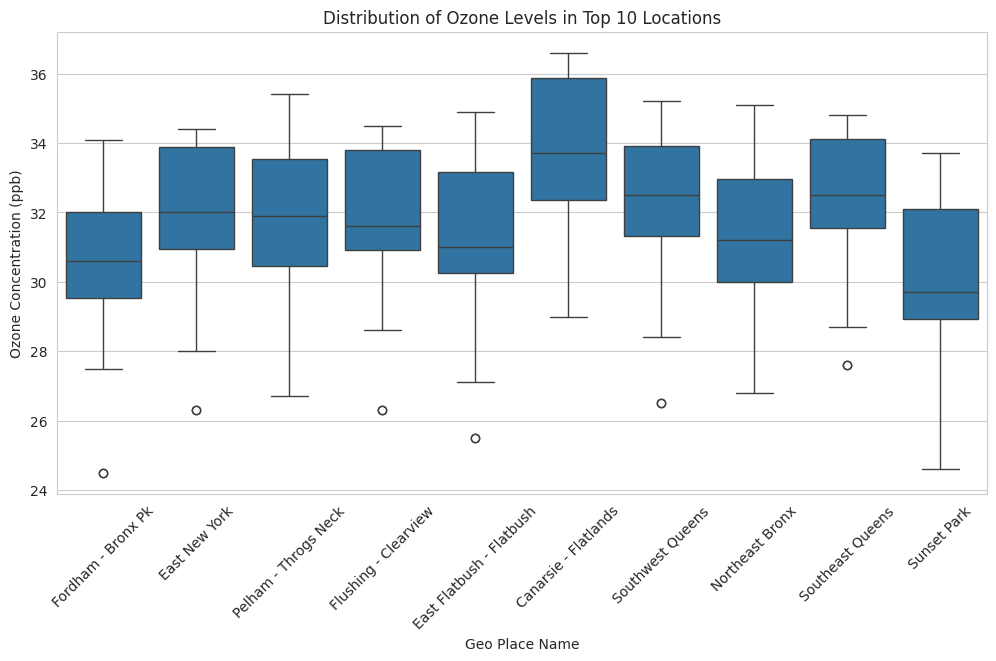

In [50]:
# Convert Start_Date to datetime
df['Start_Date'] = pd.to_datetime(df['Start_Date'], errors='coerce')

# Filter for Ozone data
ozone_df = df[df['Name'] == 'Ozone (O3)'].dropna(subset=['Start_Date', 'Data Value'])

# Extract Year from Start_Date
ozone_df['Year'] = ozone_df['Start_Date'].dt.year

# Plot 1: Line Plot of Average Ozone Levels Over Years
plt.figure(figsize=(10, 5))
sns.lineplot(data=ozone_df, x='Year', y='Data Value', estimator='mean', ci=None)
plt.title('Average Ozone (O3) Levels Over Years')
plt.ylabel('Ozone Concentration (ppb)')
plt.grid(True)
plt.show()

# Plot 2: Boxplot for Ozone Levels by Location
plt.figure(figsize=(12, 6))
top_locations = ozone_df['Geo Place Name'].value_counts().nlargest(10).index
sns.boxplot(data=ozone_df[ozone_df['Geo Place Name'].isin(top_locations)],
            x='Geo Place Name', y='Data Value')
plt.title('Distribution of Ozone Levels in Top 10 Locations')
plt.xticks(rotation=45)
plt.ylabel('Ozone Concentration (ppb)')
plt.show()

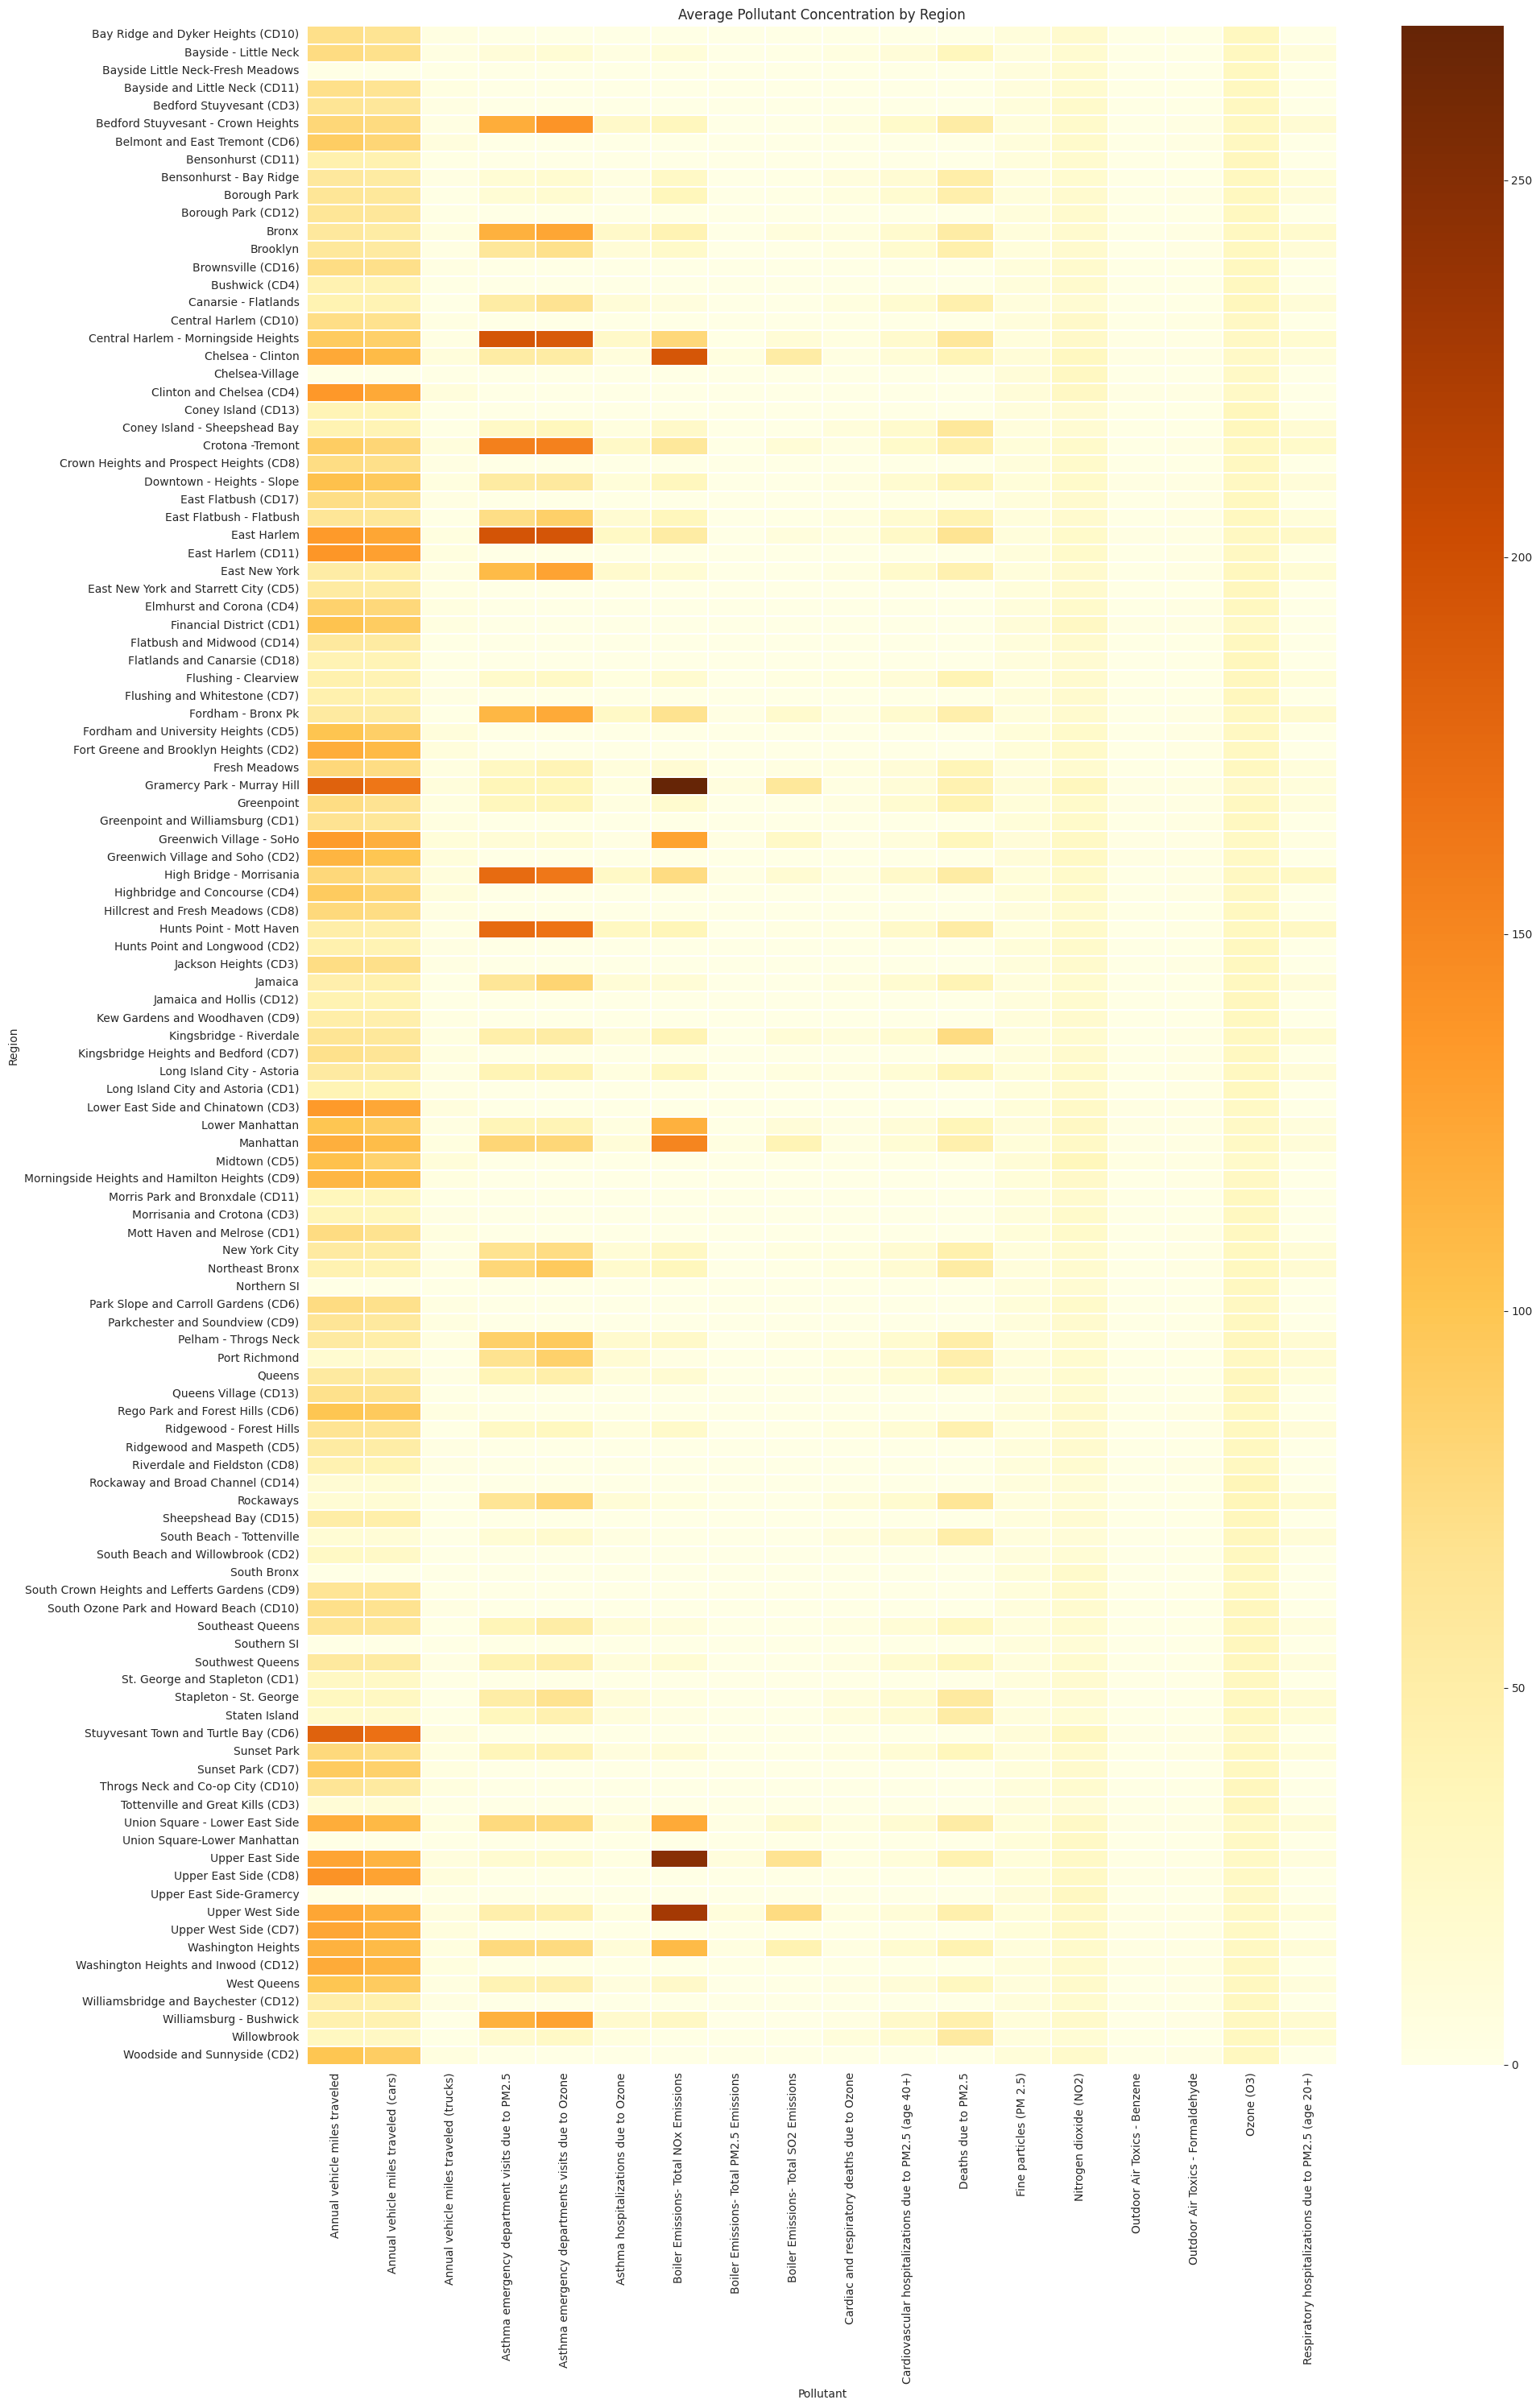

In [51]:
# Group average data for each pollutant per region
pivot_df = df.pivot_table(values='Data Value', index='Geo Place Name', columns='Name', aggfunc='mean')

# Heatmap
plt.figure(figsize=(20, 30))
sns.heatmap(pivot_df.fillna(0), cmap='YlOrBr', linewidths=0.1)
plt.title('Average Pollutant Concentration by Region')
plt.xlabel('Pollutant')
plt.ylabel('Region')
plt.tight_layout()
plt.show()




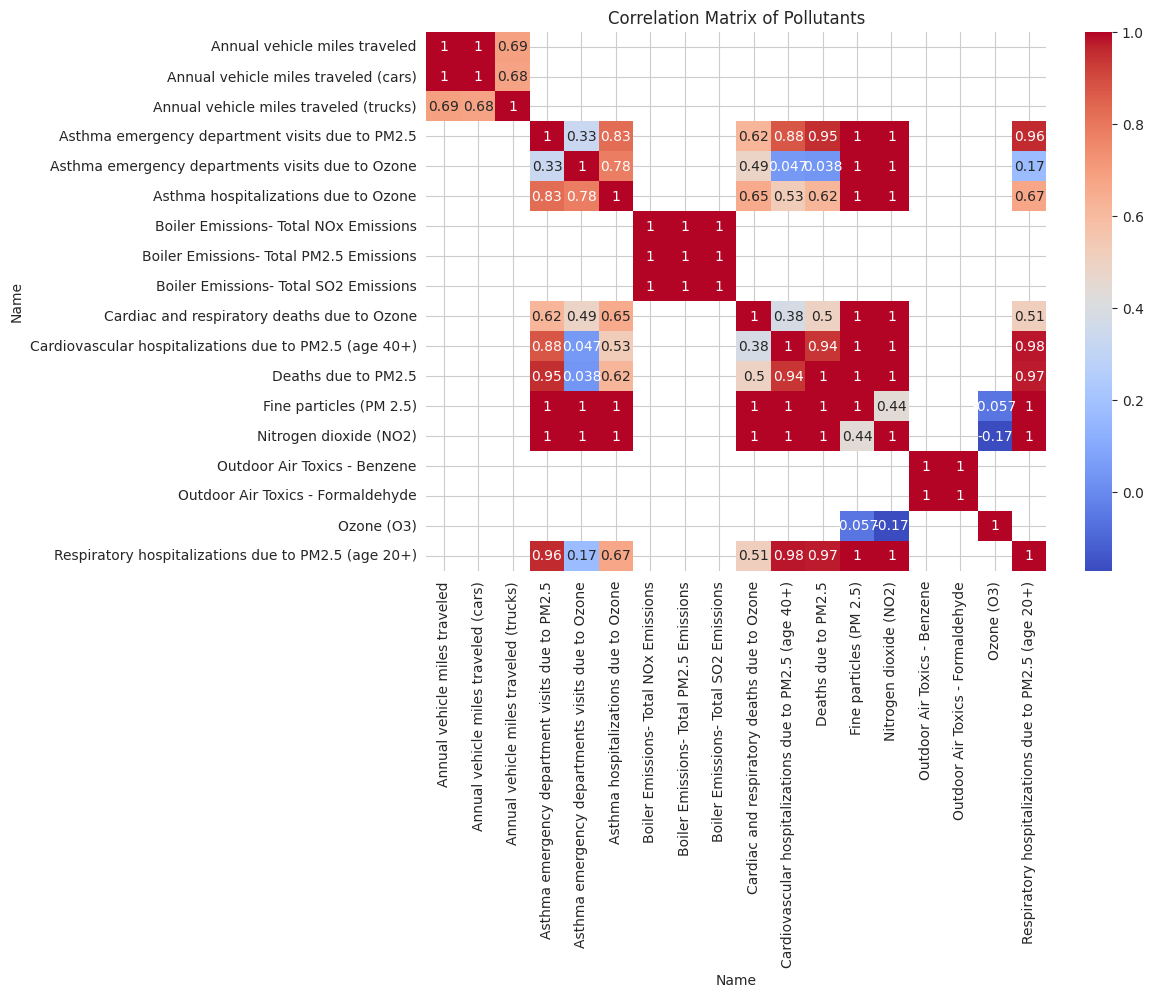

In [52]:
# Create pivot table
corr_df = df.pivot_table(index='Start_Date', columns='Name', values='Data Value', aggfunc='mean')

# Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Pollutants')
plt.show()




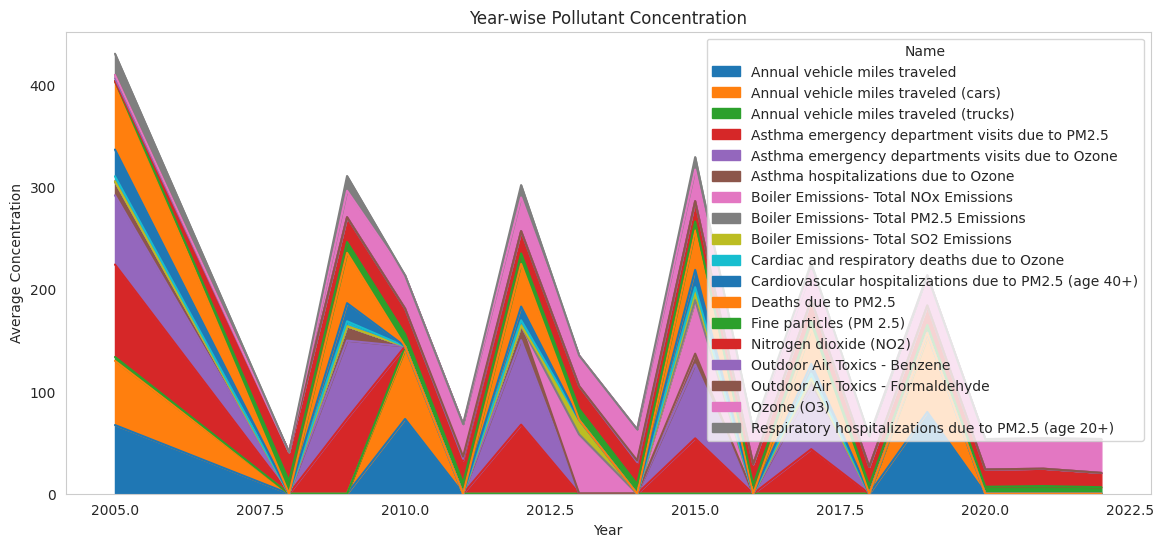

In [53]:
df['Start_Date'] = pd.to_datetime(df['Start_Date'], errors='coerce')
df['Year'] = df['Start_Date'].dt.year
aqi_df = df[df['Name'].str.contains('AQI', na=False)]


# Area chart: stacked pollutant trends
pivot_area = df.pivot_table(index='Year', columns='Name', values='Data Value', aggfunc='mean')
pivot_area.fillna(0).plot.area(figsize=(14, 6), title='Year-wise Pollutant Concentration')
plt.ylabel('Average Concentration')
plt.grid()
plt.show()


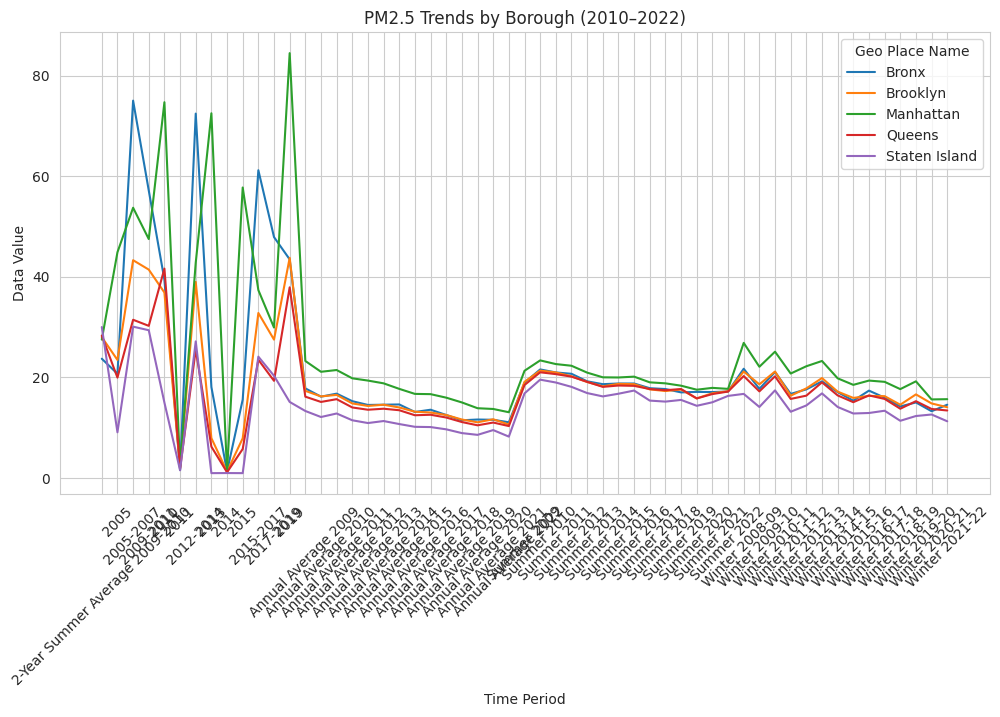

In [54]:
# Filter borough-level data
borough_pm = df[df['Geo Type Name'] == 'Borough'].groupby(['Geo Place Name', 'Time Period'])['Data Value'].mean().reset_index()
borough_no2 = df[df['Name'] == 'Nitrogen dioxide (NO2)'].groupby('Geo Place Name')['Data Value'].mean().reset_index()

# Line Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=borough_pm, x='Time Period', y='Data Value', hue='Geo Place Name')
plt.title('PM2.5 Trends by Borough (2010–2022)')
plt.xticks(rotation=45)
plt.show()




In [55]:



# Create the Dash app
app = Dash(__name__)

# Layout of the Dashboard
app.layout = html.Div([
    html.H1('Air Quality Dashboard', style={'textAlign': 'center'}),

    html.Div([
        html.Label('Select Pollutant:'),
        dcc.Dropdown(
            id='pollutant-dropdown',
            options=[{'label': pollutant, 'value': pollutant} for pollutant in df['Name'].unique()],
            value='Ozone (O3)'
        ),
    ], style={'width': '50%', 'margin': 'auto'}),

    html.Br(),

    dcc.Graph(id='trend-graph'),

    html.Br(),

    dcc.Graph(id='region-bar-graph')
])

# Callbacks to update graphs dynamically
@app.callback(
    Output('trend-graph', 'figure'),
    Output('region-bar-graph', 'figure'),
    Input('pollutant-dropdown', 'value')
)
def update_graphs(selected_pollutant):
    filtered_df = df[df['Name'] == selected_pollutant]

    # Trend over Years
    fig1 = px.bar(
        filtered_df.groupby('Year')['Data Value'].mean().reset_index(),
        x='Year',
        y='Data Value',
        title=f'Average {selected_pollutant} Level Over Years',
        color='Data Value',
        color_continuous_scale='viridis'
    )

    # Top Regions
    fig2 = px.bar(
        filtered_df.groupby('Geo Place Name')['Data Value'].mean().sort_values(ascending=False).head(15).reset_index(),
        x='Data Value',
        y='Geo Place Name',
        orientation='h',
        title=f'Top 15 Regions by Average {selected_pollutant} Level',
        color='Data Value',
        color_continuous_scale='plasma'
    )

    return fig1, fig2

# Run the app
if __name__ == '__main__':
    app.run(debug=True)


<IPython.core.display.Javascript object>

<ipython-input-57-979129b76195>:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-57-979129b76195>:44: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




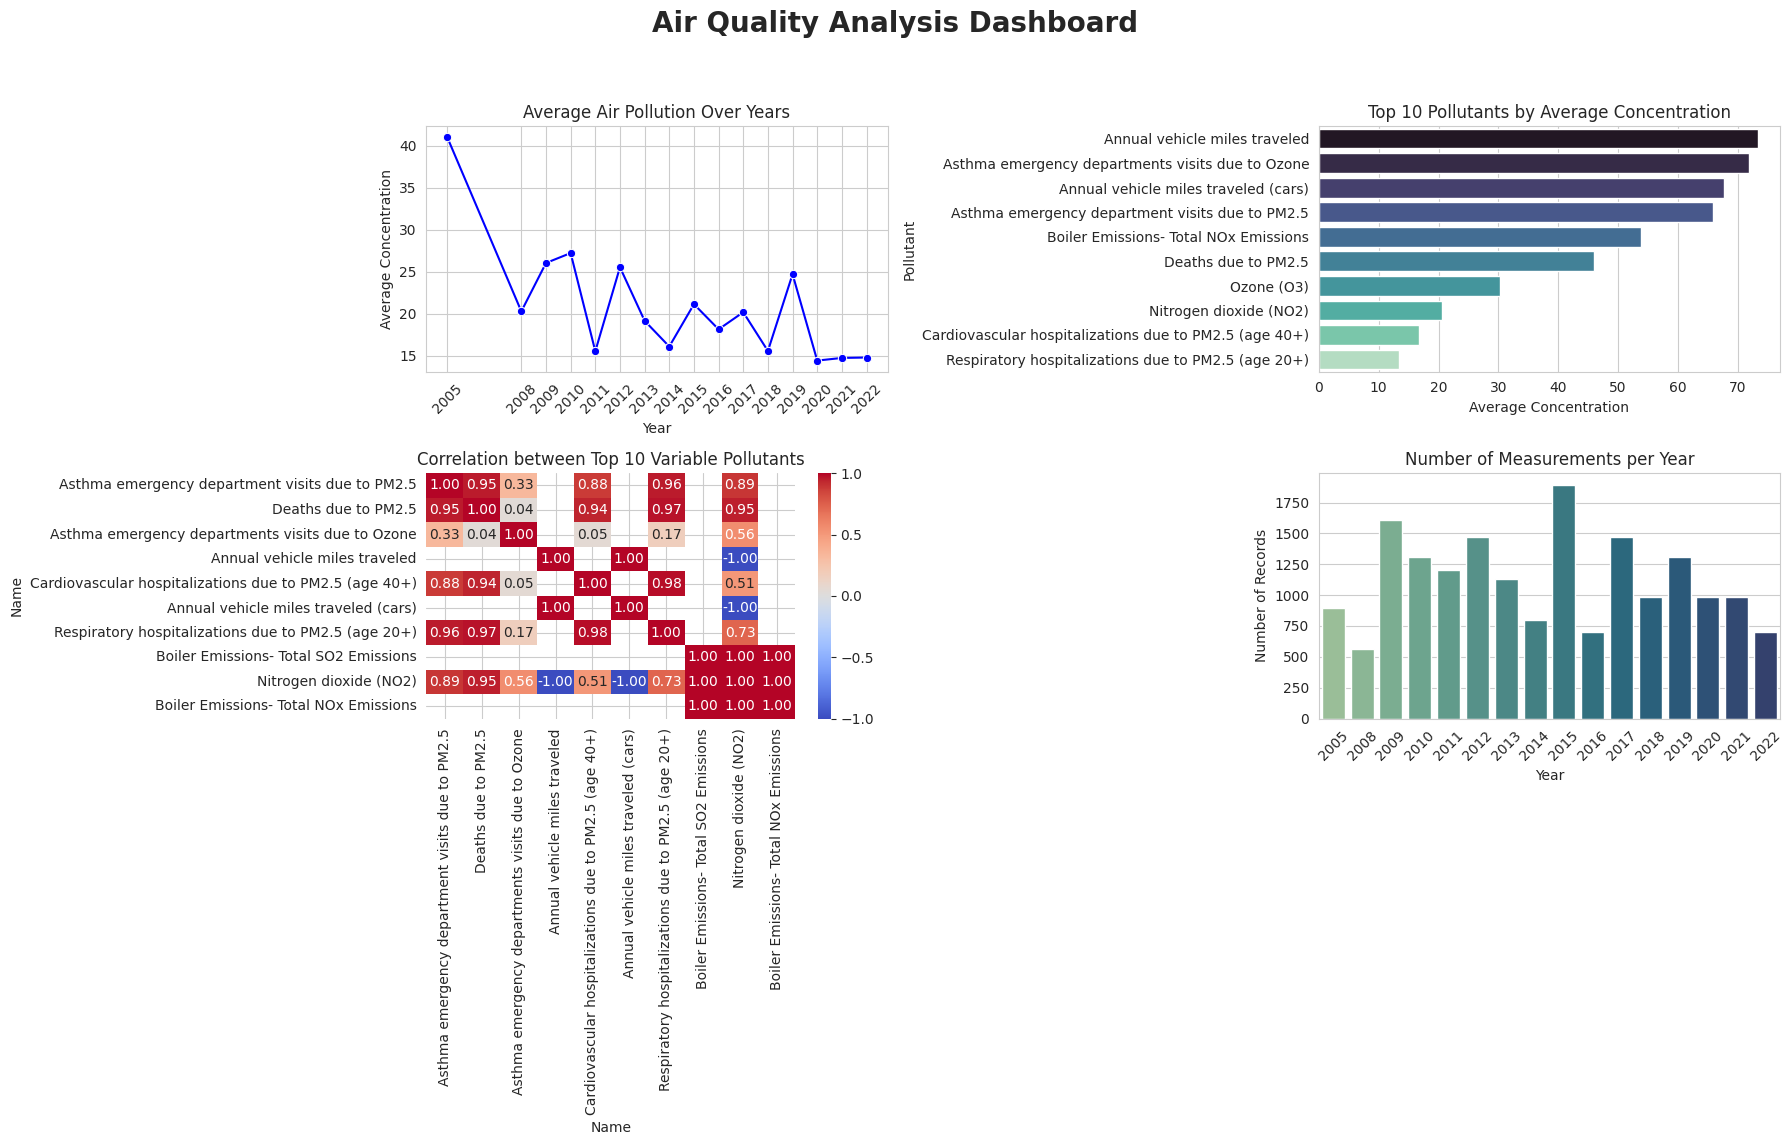

In [57]:
# Ensure correct data types
df['Year'] = df['Year'].astype(int)

# Set Seaborn style
sns.set_style('whitegrid')

# Create the figure
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Air Quality Analysis Dashboard', fontsize=20, fontweight='bold')

# --- Plot 1: Average pollutant concentration over years ---
avg_pollutant = df.groupby('Year')['Data Value'].mean().sort_index()
sns.lineplot(x=avg_pollutant.index, y=avg_pollutant.values, marker='o', ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Average Air Pollution Over Years')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Average Concentration')
axes[0, 0].set_xticks(avg_pollutant.index[::1])  # Show all years or skip if too crowded
axes[0, 0].tick_params(axis='x', rotation=45)

# --- Plot 2: Top 10 pollutants overall ---
top_pollutants = df.groupby('Name')['Data Value'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_pollutants.values, y=top_pollutants.index, ax=axes[0, 1], palette='mako')
axes[0, 1].set_title('Top 10 Pollutants by Average Concentration')
axes[0, 1].set_xlabel('Average Concentration')
axes[0, 1].set_ylabel('Pollutant')

# --- Plot 3: Correlation heatmap with reduced features ---
# Pivot table for pollutants per year
pivot_df = df.pivot_table(values='Data Value', index='Year', columns='Name', aggfunc='mean')

# Select top 10 pollutants by variance (most informative)
if pivot_df.shape[1] >= 2:
    top_vars = pivot_df.var().sort_values(ascending=False).head(10).index
    reduced_corr = pivot_df[top_vars].corr()
    sns.heatmap(reduced_corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1, 0], cbar=True)
    axes[1, 0].set_title('Correlation between Top 10 Variable Pollutants')
else:
    axes[1, 0].text(0.5, 0.5, 'Not enough data for correlation',
                   ha='center', va='center', fontsize=12)
    axes[1, 0].set_axis_off()

# --- Plot 4: Number of records per year ---
yearly_counts = df['Year'].value_counts().sort_index()
sns.barplot(x=yearly_counts.index, y=yearly_counts.values, ax=axes[1, 1], palette='crest')
axes[1, 1].set_title('Number of Measurements per Year')
axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Number of Records')
axes[1, 1].tick_params(axis='x', rotation=45)

# Layout adjustment
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
